# End to End ML model with placement csv dataset 

In [30]:
import numpy as np 
import pandas as pd 


In [31]:
df = pd.read_csv('placement.csv')

In [32]:
df.iloc[:,1:]

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0
...,...,...,...
95,4.3,200.0,0
96,4.4,42.0,0
97,6.7,182.0,1
98,6.3,103.0,1


In [33]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [34]:
df.shape

(100, 4)

# Steps

# 0. Preprocess + EDA + Feature Selection
# 1. Extract input and output cols
# 2. Scale the values
# 3. Train test split
# 4. Train the model
# 5. Evaluate the model/model selection
# 6. Deploy the model
     

In [35]:
import matplotlib.pyplot as plt

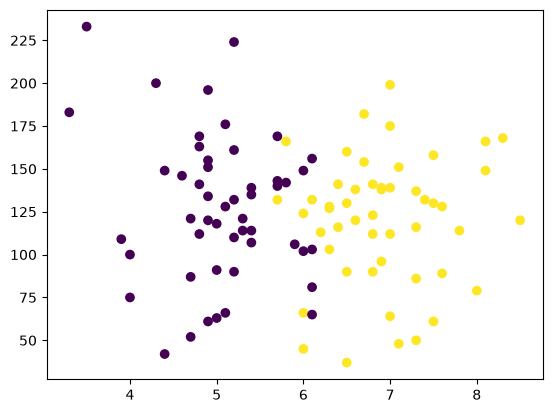

In [36]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [37]:
X = df.iloc[: , 1 : 3]
y = df.iloc[: , -1]
X


,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [38]:
y


0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64

In [39]:
from sklearn.model_selection import train_test_split
X_train , X_test, y_train , y_test = train_test_split(X,y,test_size = 0.1)

In [40]:
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()

In [41]:
X_train = scaler.fit_transform(X_train)
X_train

array([[-1.73768845, -1.22682955],
       [-0.96261816,  1.77951019],
       [-1.13485601, -0.92868015],
       [ 0.07080889,  0.78567887],
       [ 0.75976026,  0.33845478],
       [ 1.19035487,  0.18938008],
       [-1.22097493,  0.53722104],
       [-0.96261816, -0.10876932],
       [ 0.15692781, -0.2826898 ],
       [-0.96261816,  0.76083309],
       [-0.7042614 ,  0.90990778],
       [-0.87649924, -0.15846088],
       [ 0.75976026, -0.70506811],
       [-0.18754787,  1.0341367 ],
       [-0.27366679,  1.10867405],
       [-1.04873708,  0.95959935],
       [-0.27366679,  0.46268369],
       [ 1.96542516,  1.08382826],
       [ 0.67364134, -0.30753558],
       [-0.01531003,  0.61175839],
       [-1.04873708,  1.10867405],
       [-0.7042614 ,  2.47519211],
       [ 1.53483055, -0.25784401],
       [-1.39321277, -2.04674039],
       [-0.96261816,  0.66144995],
       [-1.13485601, -1.79828256],
       [ 0.41528458,  0.885062  ],
       [-0.61814248, -0.25784401],
       [ 0.07080889,

In [42]:
X_test = scaler.transform(X_test)
X_test

array([[-0.53202356, -0.43176449],
       [-0.53202356,  0.26391743],
       [-0.01531003, -0.55599341],
       [-1.39321277,  0.61175839],
       [ 0.32916565,  0.41299213],
       [ 1.27647379, -1.57467051],
       [ 0.07080889, -1.47528738],
       [-0.79038032,  1.28259453],
       [-1.04873708, -0.30753558],
       [ 0.32916565, -0.20815245]])

In [43]:
from sklearn.linear_model import LogisticRegression

In [44]:
clf = LogisticRegression()

In [45]:
# model training
clf.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [46]:
clf.predict(X_test)

array([0, 0, 1, 0, 1, 1, 1, 0, 0, 1])

In [47]:
y_test

81    0
49    0
62    0
88    0
54    1
44    1
56    0
15    0
59    0
13    1
Name: placement, dtype: int64

In [48]:
y_pred = clf.predict(X_test)

In [49]:
y_pred

array([0, 0, 1, 0, 1, 1, 1, 0, 0, 1])

In [51]:
from sklearn.metrics import accuracy_score
accuracy_score (y_test,y_pred)

0.8

<Axes: >

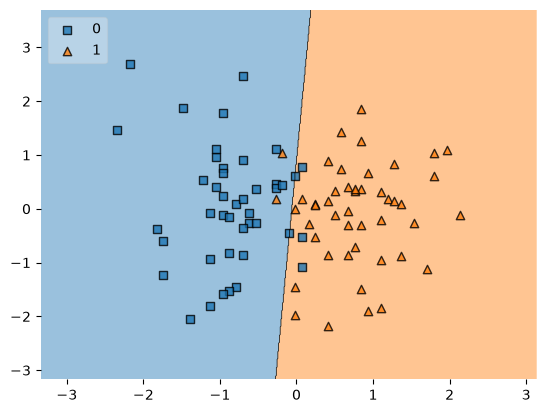

In [ ]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)

In [58]:
import pickle
pickle.dump (clf, open ('model.pkl', 'wb'))

## Here model.pkl file is generated this file  is the main model file that can now predict perfect with input 
